In [1]:
from func_file_io import load_data
from dotenv import load_dotenv
from pathlib import Path
import os

import os
import logging
from pathlib import Path
import geopandas as gpd
from dotenv import load_dotenv
import concurrent.futures
import xarray as xr
import rioxarray
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
from affine import Affine
import rasterio
from shapely.geometry import box, shape
import numpy as np
from func_data_preprocessing import extract_s1cd_filename_part
from func_file_io import load_data, transform_crs
from func_helper import parse_custom_colors, format_label
from func_plots import plot_stacked_bar_chart
import shutil
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [19]:
print("Set up environment variables ...")
# Load environment variables from a .env file
env_path = Path('/work/sy58xupo-CleaningSpace/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)
# Retrieve and parse custom color settings from environment variables
custom_colors_json = os.getenv('COLORS')
custom_colors = parse_custom_colors(custom_colors_json)

Set up environment variables ...


In [20]:
custom_colors

{'wind': '#1f77b4',
 'fire': '#d62728',
 'defoliators': '#BF40BF',
 'drought': '#FFBA08',
 'bark_beetle': '#714709'}

In [ ]:
import geopandas as gpd

# Define the folder paths
ids_path = "/work/sy58xupo-CleaningSpace/ForExD-WP1-P1/results_clean/region_08_dca_filtered_ids_usda_polygons.shp"
s1cd_path = "/work/sy58xupo-CleaningSpace/ForExD-WP1-P1/results_clean/s1dm.shp"

# Load the shapefiles
ids_data = gpd.read_file(ids_path)
s1cd_data = gpd.read_file(s1cd_path)

# Display basic information about the files
print("IDS Data:")
ids_data

IDS Data:


,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,ID_E,ID_O,O_Year,O_DCA_ID,O_Y_diff,area_km2,IDX_D,geometry
0,bark_beetle,2016,8,1,23857,None,NaN,None,NaN,0.037331,bark_beetle_2016_0,"POLYGON ((-91.17886 31.27813, -91.17918 31.277..."
1,bark_beetle,2016,8,1,23858,None,NaN,None,NaN,0.044889,bark_beetle_2016_1,"POLYGON ((-83.74712 35.43908, -83.74695 35.439..."
2,bark_beetle,2016,8,1,23859,None,NaN,None,NaN,0.032216,bark_beetle_2016_2,"POLYGON ((-83.65254 35.39814, -83.65178 35.398..."
3,fire,2016,8,8,23860,None,NaN,None,NaN,0.147280,fire_2016_3,"POLYGON ((-83.8368 35.4074, -83.83771 35.40758..."
4,fire,2016,8,8,23861,None,NaN,None,NaN,0.106956,fire_2016_4,"POLYGON ((-87.43671 34.31719, -87.43684 34.317..."
...,...,...,...,...,...,...,...,...,...,...,...,...
2486,defoliators,2020,8,2,26838,24490,2018.0,defoliators,-2.0,10.858748,defoliators_2020_2486,"POLYGON ((-91.65263 30.3493, -91.64905 30.3457..."
2487,defoliators,2020,8,2,26838,26176,2019.0,defoliators,-1.0,10.858748,defoliators_2020_2487,"POLYGON ((-91.65263 30.3493, -91.64905 30.3457..."
2488,defoliators,2020,8,2,26839,27376,2022.0,defoliators,2.0,3.033830,defoliators_2020_2488,"POLYGON ((-90.62783 30.12362, -90.62922 30.124..."
2489,defoliators,2020,8,2,26841,24454,2018.0,defoliators,-2.0,8.470990,defoliators_2020_2489,"POLYGON ((-90.69715 30.13595, -90.69038 30.129..."


In [3]:
print("\nS1CD Data:")
s1cd_data


S1CD Data:


,IDX_D,S1_YEAR,S1_TILE,area_left,S1CD_IDX,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,ID_E,ID_O,O_Year,O_DCA_ID,O_Y_diff,area_km2,area_right,area,geometry
0,bark_beetle_2018_1027,2018,E090N024T3,0.001067,1027,bark_beetle,2018,8,1,25169,None,NaN,None,NaN,0.003516,0.832899,0.001067,"MULTIPOLYGON (((-89.65304 32.04704, -89.65304 ..."
1,bark_beetle_2018_1052,2018,E090N024T3,0.001067,1052,bark_beetle,2018,8,1,25194,None,NaN,None,NaN,0.003516,0.820468,0.001067,"MULTIPOLYGON (((-89.65304 32.04704, -89.65304 ..."
2,bark_beetle_2018_1053,2018,E090N024T3,0.001067,1053,bark_beetle,2018,8,1,25195,None,NaN,None,NaN,0.001563,0.822090,0.001067,"MULTIPOLYGON (((-89.65247 32.04743, -89.65247 ..."
3,bark_beetle_2018_1054,2018,E090N024T3,0.000534,1054,bark_beetle,2018,8,1,25196,None,NaN,None,NaN,0.028124,0.849946,0.000534,"MULTIPOLYGON (((-89.65381 32.06405, -89.65304 ..."
4,bark_beetle_2018_1055,2018,E090N024T3,0.002135,1055,bark_beetle,2018,8,1,25197,None,NaN,None,NaN,0.028507,0.884742,0.002135,"MULTIPOLYGON (((-89.65361 32.08468, -89.65361 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,defoliators_2016_103,2016,E096N027T3,0.001613,103,defoliators,2016,8,2,24023,None,NaN,None,NaN,0.104911,1.445765,0.001613,"MULTIPOLYGON (((-80.48934 32.6967, -80.48953 3..."
1225,defoliators_2016_107,2016,E096N027T3,0.053757,107,defoliators,2016,8,2,24030,None,NaN,None,NaN,1.248928,2.642961,0.053757,"MULTIPOLYGON (((-80.47004 32.67167, -80.46966 ..."
1226,defoliators_2016_110,2016,E096N027T3,0.001613,110,defoliators,2016,8,2,24034,None,NaN,None,NaN,0.370951,2.315840,0.001613,"MULTIPOLYGON (((-80.48131 32.68409, -80.4815 3..."
1227,defoliators_2016_96,2016,E096N027T3,0.003762,96,defoliators,2016,8,2,24006,None,NaN,None,NaN,0.480361,2.891845,0.003762,"MULTIPOLYGON (((-80.4559 32.6516, -80.4559 32...."


In [37]:
# Ensure both datasets have the same coordinate reference system (CRS)
if ids_data.crs != s1cd_data.crs:
    s1cd_data = s1cd_data.to_crs(ids_data.crs)

# Filter for common IDX_D values
common_idx_d = set(ids_data["IDX_D"]).intersection(s1cd_data["IDX_D"])

# Filter both datasets for common IDX_D values
ids_common = ids_data[ids_data["IDX_D"].isin(common_idx_d)]
s1cd_common = s1cd_data[s1cd_data["IDX_D"].isin(common_idx_d)]

In [48]:
import geopandas as gpd
import pandas as pd

# Initialize a result list to store the calculations
results = []

# Loop through common IDX_Ds
for idx_d in common_idx_d:
    # Get the corresponding polygons from both datasets
    ids_poly = ids_common[ids_common["IDX_D"] == idx_d].geometry.union_all()
    s1cd_poly = s1cd_common[s1cd_common["IDX_D"] == idx_d].geometry.union_all()

    # Calculate the areas
    ids_area = ids_poly.area
    intersection_area = ids_poly.intersection(s1cd_poly).area

    # Calculate percentage coverage
    percentage = (intersection_area / ids_area) * 100 if ids_area > 0 else 0

    # Calculate the area of the S1CD polygon
    s1cd_area = s1cd_poly.area
    # Calculate percentage coverage of S1CD
    percentage_s1cd = (intersection_area / s1cd_area) * 100 if s1cd_area > 0 else 0

    # Get DCA_ID for this IDX_D (assuming it exists in both datasets)
    dca_id = ids_common[ids_common["IDX_D"] == idx_d]["DCA_ID"].iloc[0]

    # Append results
    results.append({"IDX_D": idx_d, "DCA_ID": dca_id, "percentage_ids": percentage, "percentage_s1cd": percentage_s1cd})

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# # Save to a CSV file (optional)
# results_df.to_csv("coverage_results.csv", index=False)

# # Display the first few rows of the results
# print(results_df.head())
results_df

,IDX_D,DCA_ID,percentage_ids,percentage_s1cd
0,bark_beetle_2018_776,bark_beetle,0.000000,0.000000
1,defoliators_2019_1594,defoliators,0.182973,85.714286
2,wind_2018_1578,wind,15.438276,21.435778
3,bark_beetle_2018_678,bark_beetle,89.549966,1.603608
4,wind_2018_1556,wind,0.446213,0.329348
...,...,...,...,...
1221,wind_2020_1838,wind,15.351145,29.544257
1222,wind_2018_529,wind,2.264266,5.880551
1223,wind_2020_1882,wind,0.705525,11.794413
1224,wind_2020_1867,wind,15.444833,37.362339


/tmp/ipykernel_1002532/930147352.py:22: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(dca_id_df['percentage_ids'], fill=False, label=dca_id, color=custom_colors[dca_id], ax=axes[0])
/tmp/ipykernel_1002532/930147352.py:28: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(dca_id_df['percentage_s1cd'], fill=False, label=dca_id, color=custom_colors[dca_id], ax=axes[1])


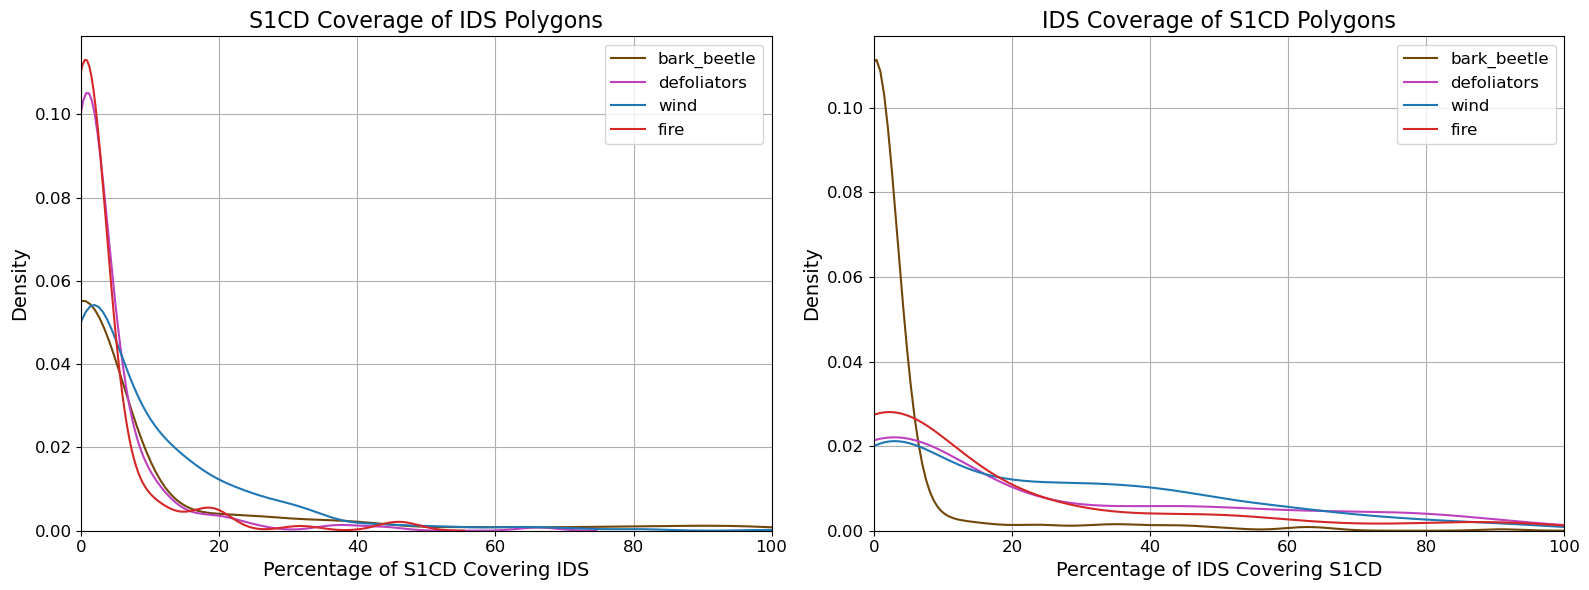

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming the table is stored in a pandas DataFrame 'results_df'
# Define custom colors for each DCA_ID
custom_colors = {
    'wind': '#1f77b4',
    'fire': '#d62728',
    'defoliators': '#BF40BF',
    'drought': '#FFBA08',
    'bark_beetle': '#714709'
}

# Create subplots with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: S1CD coverage of IDS polygons
for dca_id in results_df['DCA_ID'].unique():
    if dca_id in custom_colors:
        dca_id_df = results_df[results_df['DCA_ID'] == dca_id]
        sns.kdeplot(dca_id_df['percentage_ids'], fill=False, label=dca_id, color=custom_colors[dca_id], ax=axes[0])

# Plot 2: IDS coverage of S1CD polygons
for dca_id in results_df['DCA_ID'].unique():
    if dca_id in custom_colors:
        dca_id_df = results_df[results_df['DCA_ID'] == dca_id]
        sns.kdeplot(dca_id_df['percentage_s1cd'], fill=False, label=dca_id, color=custom_colors[dca_id], ax=axes[1])

# Customize both plots
axes[0].set_title('S1CD Coverage of IDS Polygons', fontsize=16)
axes[0].set_xlabel('Percentage of S1CD Covering IDS', fontsize=14)
axes[0].set_ylabel('Density', fontsize=14)
axes[0].set_xlim(0, 100)  # Cut off the x-axis at 100 and avoid negative values
axes[0].tick_params(axis='both', labelsize=12)
axes[0].legend(loc='upper right', fontsize=12)

axes[1].set_title('IDS Coverage of S1CD Polygons', fontsize=16)
axes[1].set_xlabel('Percentage of IDS Covering S1CD', fontsize=14)
axes[1].set_ylabel('Density', fontsize=14)
axes[1].set_xlim(0, 100)  # Cut off the x-axis at 100 and avoid negative values
axes[1].tick_params(axis='both', labelsize=12)
axes[1].legend(loc='upper right', fontsize=12)

# Display grid
for ax in axes:
    ax.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


/tmp/ipykernel_1002532/239140267.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(dca_id_df['Percentage'], fill=False, label=dca_id, color=custom_colors[dca_id])


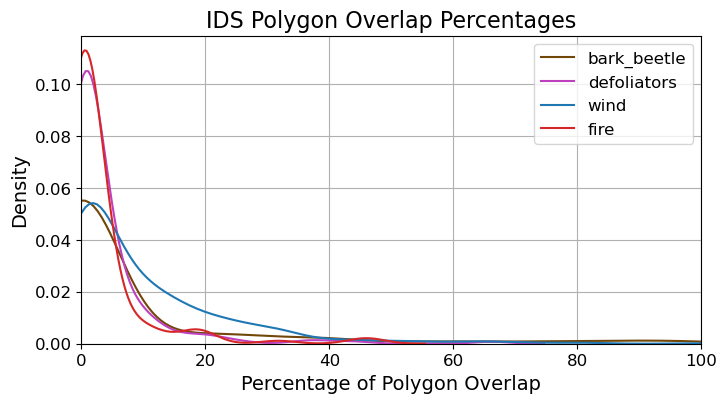

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming the table is stored in a pandas DataFrame 'results_df'
# Initialize the plot
plt.figure(figsize=(8, 4))

# Iterate over each unique DCA_ID and plot the density
unique_dca_ids = results_df['DCA_ID'].unique()
for dca_id in unique_dca_ids:
    if dca_id in custom_colors:
        dca_id_df = results_df[results_df['DCA_ID'] == dca_id]
        sns.kdeplot(dca_id_df['percentage'], fill=False, label=dca_id, color=custom_colors[dca_id])


# Customize the plot
plt.title('IDS Polygon Overlap Percentages', fontsize=16)
plt.xlabel('Percentage of Polygon Overlap', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xlim(0, 100)  # Cut off the x-axis at 100 and avoid negative values
plt.xticks(fontsize=12)  # Increase the font size for x-axis ticks
plt.yticks(fontsize=12)  # Increase the font size for y-axis ticks
plt.legend(loc='upper right',fontsize=12)  # Increase the font size for legend


plt.grid(True)

# Show the plot
plt.show()


/tmp/ipykernel_1002532/2228295420.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(dca_id_df['Percentage'], fill=False, label=dca_id, color=custom_colors[dca_id])


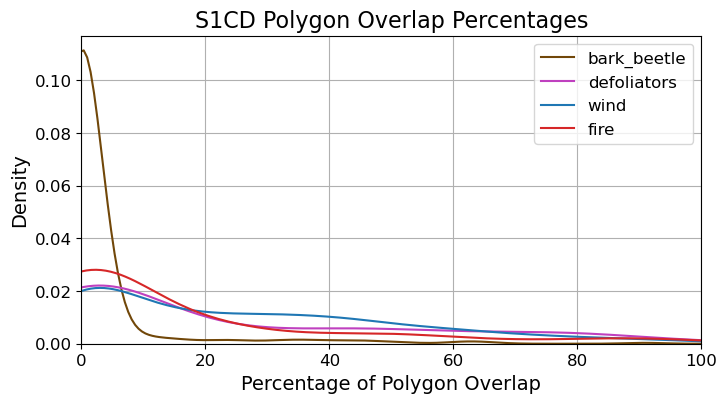

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming the table is stored in a pandas DataFrame 'results_df'
# Initialize the plot
plt.figure(figsize=(8, 4))

# Iterate over each unique DCA_ID and plot the density
unique_dca_ids = results_df['DCA_ID'].unique()
for dca_id in unique_dca_ids:
    if dca_id in custom_colors:
        dca_id_df = results_df[results_df['DCA_ID'] == dca_id]
        sns.kdeplot(dca_id_df['percentage_s1cd'], fill=False, label=dca_id, color=custom_colors[dca_id])


# Customize the plot
plt.title('S1CD Polygon Overlap Percentages', fontsize=16)
plt.xlabel('Percentage of Polygon Overlap', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xlim(0, 100)  # Cut off the x-axis at 100 and avoid negative values
plt.xticks(fontsize=12)  # Increase the font size for x-axis ticks
plt.yticks(fontsize=12)  # Increase the font size for y-axis ticks
plt.legend(loc='upper right',fontsize=12)  # Increase the font size for legend


plt.grid(True)

# Show the plot
plt.show()
